# Cross-Domain & Out-of-Domain Experiments

Transfer learning experiments using handcrafted linguistic features.
- **Step 1**: Define feature sets (joint-top, shared, shared-relaxed)
- **Step 2**: Cross-domain Stratified 5-fold CV on combined ADReSS + CCC
- **Step 3**: Out-of-domain transfer (ADReSS→CCC and CCC→ADReSS)
- **Step 4**: Interpretation summary

> **Leakage prevention**: imputer and scaler are always fit on training data only and applied to validation/test data. No feature selection is redone inside CV.

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix,
)
import os
import warnings
warnings.filterwarnings('ignore')


In [2]:
OUTPUT_DIR = '../outputs/cross_out_domain_experiments_output'
VIZ_DIR    = '../visualizations/cross_out_domain_experiments_visualizations'

ADRESS_FEATURES_PATH = '../outputs/adress_extractedfeatures.csv'
CCC_FEATURES_PATH    = '../outputs/ccc_extractedfeatures.csv'
ADRESS_RANKED_PATH   = '../outputs/in_domain_feature_stability_output/adress_stable_ranked_features.csv'
CCC_RANKED_PATH      = '../outputs/in_domain_feature_stability_output/ccc_stable_ranked_features.csv'

ADRESS_EXCLUDE = ['ID', 'age', 'gender', 'mmse', 'aggregated_utterances']
CCC_EXCLUDE    = ['id', 'individual', 'aggregated_utterances']
TARGET = 'diagnosis'

# L2 LR params as specified in instructions
LR_PARAMS = dict(penalty='l2', solver='liblinear', class_weight='balanced', max_iter=5000)

# Threshold: if shared_features has fewer than this many features, also use relaxed
MIN_SHARED_FEATURES = 5

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(VIZ_DIR,    exist_ok=True)


## Load Data and Ranked Features

Reuse the already-extracted feature tables and pre-computed stability rankings from in-domain notebooks.

In [3]:
adress_df     = pd.read_csv(ADRESS_FEATURES_PATH)
ccc_df        = pd.read_csv(CCC_FEATURES_PATH)
adress_ranked = pd.read_csv(ADRESS_RANKED_PATH)
ccc_ranked    = pd.read_csv(CCC_RANKED_PATH)

# Extract numeric feature columns (exclude metadata)
adress_feat_cols = [
    c for c in adress_df.columns if c not in ADRESS_EXCLUDE + [TARGET]
]
adress_feat_cols = adress_df[adress_feat_cols].select_dtypes(include=[np.number]).columns.tolist()

ccc_feat_cols = [
    c for c in ccc_df.columns if c not in CCC_EXCLUDE + [TARGET]
]
ccc_feat_cols = ccc_df[ccc_feat_cols].select_dtypes(include=[np.number]).columns.tolist()

X_adress = adress_df[adress_feat_cols].copy()
y_adress = adress_df[TARGET].values
X_ccc    = ccc_df[ccc_feat_cols].copy()
y_ccc    = ccc_df[TARGET].values

print(f'ADReSS: {X_adress.shape[0]} samples, {X_adress.shape[1]} features')
print(f'CCC   : {X_ccc.shape[0]} samples, {X_ccc.shape[1]} features')
print(f'ADReSS ranked features loaded: {len(adress_ranked)}')
print(f'CCC ranked features loaded   : {len(ccc_ranked)}')


ADReSS: 156 samples, 46 features
CCC   : 290 samples, 46 features
ADReSS ranked features loaded: 25
CCC ranked features loaded   : 20


## Label Consistency Check

Before combining or transferring across datasets, verify that the `diagnosis` label uses the same encoding convention (0 = HC, 1 = AD) in both datasets, and that all feature columns are shared.

In [4]:
print('=== Label Consistency Check ===')
print(f'\nADReSS diagnosis distribution: {pd.Series(y_adress).value_counts().sort_index().to_dict()}')
print(f'CCC    diagnosis distribution: {pd.Series(y_ccc).value_counts().sort_index().to_dict()}')

assert set(np.unique(y_adress)) == {0, 1}, 'ADReSS labels must be binary 0/1'
assert set(np.unique(y_ccc))    == {0, 1}, 'CCC labels must be binary 0/1'
print('\nLabel encoding consistent: 0 = HC, 1 = AD in both datasets.')

# Feature overlap
shared_col_names = sorted(set(adress_feat_cols) & set(ccc_feat_cols))
adress_only = sorted(set(adress_feat_cols) - set(ccc_feat_cols))
ccc_only    = sorted(set(ccc_feat_cols)    - set(adress_feat_cols))

print(f'\nFeature columns in ADReSS : {len(adress_feat_cols)}')
print(f'Feature columns in CCC    : {len(ccc_feat_cols)}')
print(f'Shared feature columns    : {len(shared_col_names)}')

if adress_only:
    print(f'WARNING - ADReSS-only features: {adress_only}')
if ccc_only:
    print(f'WARNING - CCC-only features: {ccc_only}')
if not adress_only and not ccc_only:
    print('All feature columns present in both datasets. Safe to transfer.')


=== Label Consistency Check ===

ADReSS diagnosis distribution: {0: 78, 1: 78}
CCC    diagnosis distribution: {0: 193, 1: 97}

Label encoding consistent: 0 = HC, 1 = AD in both datasets.

Feature columns in ADReSS : 46
Feature columns in CCC    : 46
Shared feature columns    : 46
All feature columns present in both datasets. Safe to transfer.


## Step 1 — Define Feature Sets

Three feature sets are constructed from the pre-computed stability rankings:

| Set | Definition |
|-----|------------|
| `joint_top_features` | Union of top-10 stable features from ADReSS and top-10 from CCC |
| `shared_features` | Features with `selected_folds ≥ 4` AND `stable_direction=True` in **both** datasets |
| `shared_relaxed_features` | Same as above but with `selected_folds ≥ 3` threshold |

> No new data is touched here — this step only reads the pre-saved ranking CSVs.

In [5]:
def get_top_n(ranked_df, n=10):
    """Return top-N stable features sorted by (selected_folds DESC, avg_abs_coefficient DESC)."""
    stable = ranked_df[ranked_df['stable'] == True]
    return (
        stable
        .sort_values(['selected_folds', 'avg_abs_coefficient'], ascending=[False, False])
        .head(n)['feature']
        .tolist()
    )


def get_stable_features(ranked_df, min_folds):
    """Return stable features with selected_folds >= min_folds."""
    return (
        ranked_df[
            (ranked_df['stable'] == True) &
            (ranked_df['selected_folds'] >= min_folds)
        ]['feature']
        .tolist()
    )


In [6]:
# Top-10 per dataset
adress_top10 = get_top_n(adress_ranked, n=10)
ccc_top10    = get_top_n(ccc_ranked, n=10)

# Feature Set 1: union of top-10 (keep all if > 20)
joint_top_features = sorted(set(adress_top10) | set(ccc_top10))

# Lookup tables: majority_direction per feature in each dataset
adress_dir   = adress_ranked.set_index('feature')['majority_direction'].to_dict()
ccc_dir      = ccc_ranked.set_index('feature')['majority_direction'].to_dict()
adress_folds = adress_ranked.set_index('feature')['selected_folds'].to_dict()
ccc_folds    = ccc_ranked.set_index('feature')['selected_folds'].to_dict()

# Feature Set 2: stable in BOTH datasets with >= 4 folds (updated definition) # Also tried with 5 but lower results
adress_stable4 = set(get_stable_features(adress_ranked, 4))
ccc_stable4    = set(get_stable_features(ccc_ranked, 4))
shared_features = sorted(adress_stable4 & ccc_stable4)

# Feature Set 3 (relaxed): stable in BOTH datasets with >= 3 folds
adress_stable3 = set(get_stable_features(adress_ranked, 3))
ccc_stable3    = set(get_stable_features(ccc_ranked, 3))
shared_relaxed_features = sorted(adress_stable3 & ccc_stable3)

# Decide whether shared_features is too small
use_relaxed = len(shared_features) < MIN_SHARED_FEATURES

# Active shared set for experiments
active_shared = shared_relaxed_features if use_relaxed else shared_features
active_shared_label = 'shared_relaxed_features' if use_relaxed else 'shared_features'


In [7]:
def print_feature_set(name, features, adress_dir, ccc_dir):
    print(f'\n--- {name} ({len(features)} features) ---')
    for f in features:
        a = adress_dir.get(f, 'N/A')
        c = ccc_dir.get(f, 'N/A')
        conflict = ' *** DIRECTION CONFLICT ***' if a != c and a != 'N/A' and c != 'N/A' else ''
        print(f'  {f:<45} ADReSS={a:<8} CCC={c}{conflict}')


print_feature_set('joint_top_features',      joint_top_features,      adress_dir, ccc_dir)
print_feature_set('shared_features',         shared_features,         adress_dir, ccc_dir)
print_feature_set('shared_relaxed_features', shared_relaxed_features, adress_dir, ccc_dir)

print(f'\nAuto-use relaxed: {use_relaxed}'
      f' (shared_features size={len(shared_features)}, threshold={MIN_SHARED_FEATURES})')
print(f'Active shared set for experiments: "{active_shared_label}"')



--- joint_top_features (17 features) ---
  avg_Auditory_sensorimotor                     ADReSS=positive CCC=positive
  avg_Gustatory_sensorimotor                    ADReSS=N/A      CCC=positive
  avg_Mouth_sensorimotor                        ADReSS=negative CCC=negative
  avg_Olfactory_sensorimotor                    ADReSS=positive CCC=N/A
  avg_valence                                   ADReSS=positive CCC=positive
  avg_word_length                               ADReSS=negative CCC=positive *** DIRECTION CONFLICT ***
  n_adjacent_repetitions                        ADReSS=positive CCC=positive
  n_adv                                         ADReSS=positive CCC=positive
  n_aux                                         ADReSS=negative CCC=positive *** DIRECTION CONFLICT ***
  n_det                                         ADReSS=N/A      CCC=negative
  n_intj                                        ADReSS=N/A      CCC=positive
  n_low_concreteness                            ADReSS=positiv

In [8]:
def build_direction_table(features, adress_dir, ccc_dir, adress_folds, ccc_folds):
    rows = []
    for f in features:
        a_dir = adress_dir.get(f, 'N/A')
        c_dir = ccc_dir.get(f, 'N/A')
        rows.append({
            'feature': f,
            'adress_direction': a_dir,
            'ccc_direction':    c_dir,
            'same_direction':   a_dir == c_dir,
            'adress_folds':     adress_folds.get(f, 'N/A'),
            'ccc_folds':        ccc_folds.get(f, 'N/A'),
        })
    return pd.DataFrame(rows)


# Direction comparison for all three feature sets
joint_dir_df   = build_direction_table(joint_top_features,      adress_dir, ccc_dir, adress_folds, ccc_folds)
shared_dir_df  = build_direction_table(shared_features,         adress_dir, ccc_dir, adress_folds, ccc_folds)
relaxed_dir_df = build_direction_table(shared_relaxed_features, adress_dir, ccc_dir, adress_folds, ccc_folds)

print('Direction conflicts in shared_features:')
conflicts = shared_dir_df[~shared_dir_df['same_direction']]
print(conflicts[['feature','adress_direction','ccc_direction']].to_string(index=False)
      if len(conflicts) else '  None')

print('\nDirection conflicts in shared_relaxed_features:')
conflicts_r = relaxed_dir_df[~relaxed_dir_df['same_direction']]
print(conflicts_r[['feature','adress_direction','ccc_direction']].to_string(index=False)
      if len(conflicts_r) else '  None')

# ── Save feature set CSVs ──────────────────────────────────────────────────
pd.DataFrame({'feature': joint_top_features}).to_csv(
    os.path.join(OUTPUT_DIR, 'joint_top_features.csv'), index=False)
shared_dir_df.to_csv(
    os.path.join(OUTPUT_DIR, 'shared_features.csv'), index=False)
relaxed_dir_df.to_csv(
    os.path.join(OUTPUT_DIR, 'shared_relaxed_features.csv'), index=False)

# Summary table
overlap_summary = pd.DataFrame([
    {'feature_set': 'joint_top_features',      'n_features': len(joint_top_features),
     'n_direction_conflicts': int((~joint_dir_df['same_direction'] & joint_dir_df['adress_direction'].ne('N/A') & joint_dir_df['ccc_direction'].ne('N/A')).sum())},
    {'feature_set': 'shared_features',         'n_features': len(shared_features),
     'n_direction_conflicts': int((~shared_dir_df['same_direction']).sum())},
    {'feature_set': 'shared_relaxed_features', 'n_features': len(shared_relaxed_features),
     'n_direction_conflicts': int((~relaxed_dir_df['same_direction']).sum())},
])
overlap_summary.to_csv(os.path.join(OUTPUT_DIR, 'feature_overlap_summary.csv'), index=False)
print('\nFeature overlap summary:')
print(overlap_summary.to_string(index=False))
print('\nSaved: joint_top_features.csv, shared_features.csv, shared_relaxed_features.csv, feature_overlap_summary.csv')


Direction conflicts in shared_features:
        feature adress_direction ccc_direction
 aux_verb_ratio         negative      positive
avg_word_length         negative      positive
          n_aux         negative      positive

Direction conflicts in shared_relaxed_features:
        feature adress_direction ccc_direction
 aux_verb_ratio         negative      positive
avg_word_length         negative      positive
          n_aux         negative      positive

Feature overlap summary:
            feature_set  n_features  n_direction_conflicts
     joint_top_features          17                      2
        shared_features          10                      3
shared_relaxed_features          11                      3

Saved: joint_top_features.csv, shared_features.csv, shared_relaxed_features.csv, feature_overlap_summary.csv


## Step 2 — Cross-Domain Experiment

ADReSS (n=156) and CCC (n=290) are combined into a single dataset (n=446). Stratified 5-fold CV is run with **L2 logistic regression**.

**Leakage prevention per fold**:
1. `SimpleImputer` (mean) fit on training fold → applied to validation fold
2. `StandardScaler` fit on training fold → applied to validation fold
3. No new feature selection inside CV — feature lists come from Step 1 only

In [9]:
def run_stratified_cv(X, y, feature_list, n_splits=5, random_state=42, label=''):
    """Stratified K-Fold CV with L2 LR. No leakage: imputer+scaler fit on train fold only."""
    X_sub = X[feature_list].copy()
    skf   = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    fold_metrics, fold_coefs = [], []

    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X_sub, y), start=1):
        X_train, X_test = X_sub.iloc[train_idx], X_sub.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # LEAKAGE PREVENTION: fit imputer and scaler on training fold only
        imputer = SimpleImputer(strategy='mean')
        scaler  = StandardScaler()
        X_train_p = pd.DataFrame(
            scaler.fit_transform(imputer.fit_transform(X_train)), columns=feature_list)
        X_test_p  = pd.DataFrame(
            scaler.transform(imputer.transform(X_test)),           columns=feature_list)

        model = LogisticRegression(**LR_PARAMS)
        model.fit(X_train_p, y_train)

        y_pred = model.predict(X_test_p)
        y_prob = model.predict_proba(X_test_p)[:, 1]

        fold_metrics.append({
            'fold': fold_idx,
            'accuracy':  accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred, zero_division=0),
            'recall':    recall_score(y_test, y_pred, zero_division=0),
            'f1':        f1_score(y_test, y_pred, zero_division=0),
            'auc':       roc_auc_score(y_test, y_prob),
        })
        for feat, coef in zip(feature_list, model.coef_[0]):
            fold_coefs.append({'fold': fold_idx, 'feature': feat, 'coefficient': coef,
                               'direction': 'positive' if coef > 0 else 'negative'})

    fold_df  = pd.DataFrame(fold_metrics)
    coef_df  = pd.DataFrame(fold_coefs)
    avg = fold_df.drop(columns='fold').mean()
    std = fold_df.drop(columns='fold').std()

    print(f'\n{label}')
    for m in ['accuracy', 'precision', 'recall', 'f1', 'auc']:
        print(f'  {m:10s}: {avg[m]:.3f} +/- {std[m]:.3f}')

    return fold_df, avg, std, coef_df


def run_out_of_domain(X_train, y_train, X_test, y_test, feature_list, label=''):
    """Train on full training set, evaluate on test set. No leakage: imputer+scaler fit on train only."""
    X_tr = X_train[feature_list].copy()
    X_te = X_test[feature_list].copy()

    # LEAKAGE PREVENTION: fit only on training data, never on test data
    imputer = SimpleImputer(strategy='mean')
    scaler  = StandardScaler()
    X_tr_p = pd.DataFrame(
        scaler.fit_transform(imputer.fit_transform(X_tr)), columns=feature_list)
    X_te_p = pd.DataFrame(
        scaler.transform(imputer.transform(X_te)),         columns=feature_list)

    model = LogisticRegression(**LR_PARAMS)
    model.fit(X_tr_p, y_train)

    y_pred = model.predict(X_te_p)
    y_prob = model.predict_proba(X_te_p)[:, 1]

    metrics = {
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall':    recall_score(y_test, y_pred, zero_division=0),
        'f1':        f1_score(y_test, y_pred, zero_division=0),
        'auc':       roc_auc_score(y_test, y_prob),
    }
    cm      = confusion_matrix(y_test, y_pred)
    coef_df = pd.DataFrame({
        'feature':     feature_list,
        'coefficient': model.coef_[0],
        'direction':   ['positive' if c > 0 else 'negative' for c in model.coef_[0]],
    })

    print(f'\n{label}')
    for m, v in metrics.items():
        print(f'  {m:10s}: {v:.3f}')
    print(f'  Confusion matrix (rows=true, cols=pred):\n{cm}')

    return metrics, coef_df, cm


In [10]:
# Align to shared feature columns only
X_adress_aligned = adress_df[shared_col_names].copy()
X_ccc_aligned    = ccc_df[shared_col_names].copy()

X_combined = pd.concat([X_adress_aligned, X_ccc_aligned], ignore_index=True)
y_combined  = np.concatenate([y_adress, y_ccc])

print(f'Combined dataset: {X_combined.shape[0]} samples, {X_combined.shape[1]} features')
print(f'Class distribution: HC(0)={int(np.sum(y_combined==0))}, AD(1)={int(np.sum(y_combined==1))}')
print(f'Source breakdown: ADReSS={len(y_adress)}, CCC={len(y_ccc)}')


Combined dataset: 446 samples, 46 features
Class distribution: HC(0)=271, AD(1)=175
Source breakdown: ADReSS=156, CCC=290


In [11]:
print('=' * 60)
print('CROSS-DOMAIN STRATIFIED 5-FOLD CV')
print('=' * 60)

# 1. joint_top_features
cv_joint_fold, cv_joint_avg, cv_joint_std, cv_joint_coef = run_stratified_cv(
    X_combined, y_combined, joint_top_features,
    label=f'joint_top_features ({len(joint_top_features)} features)')

# 2. shared_features (always run for reference even if small)
cv_shared_fold, cv_shared_avg, cv_shared_std, cv_shared_coef = run_stratified_cv(
    X_combined, y_combined, shared_features,
    label=f'shared_features ({len(shared_features)} features)')

# 3. shared_relaxed_features
cv_relaxed_fold, cv_relaxed_avg, cv_relaxed_std, cv_relaxed_coef = run_stratified_cv(
    X_combined, y_combined, shared_relaxed_features,
    label=f'shared_relaxed_features ({len(shared_relaxed_features)} features)')

if use_relaxed:
    print(f'\n[NOTE] shared_features has only {len(shared_features)} features (< threshold {MIN_SHARED_FEATURES}).')
    print(f'       Using shared_relaxed_features ({len(shared_relaxed_features)}) as the active shared set.')


CROSS-DOMAIN STRATIFIED 5-FOLD CV

joint_top_features (17 features)
  accuracy  : 0.767 +/- 0.046
  precision : 0.695 +/- 0.051
  recall    : 0.731 +/- 0.132
  f1        : 0.707 +/- 0.071
  auc       : 0.861 +/- 0.037

shared_features (10 features)
  accuracy  : 0.735 +/- 0.049
  precision : 0.652 +/- 0.061
  recall    : 0.714 +/- 0.088
  f1        : 0.679 +/- 0.054
  auc       : 0.797 +/- 0.054

shared_relaxed_features (11 features)
  accuracy  : 0.744 +/- 0.057
  precision : 0.663 +/- 0.072
  recall    : 0.726 +/- 0.096
  f1        : 0.690 +/- 0.063
  auc       : 0.797 +/- 0.056


In [13]:
def build_results_df(experiments):
    """experiments: list of (label, feature_set, avg, std) tuples."""
    rows = []
    for label, feat_set, avg, std in experiments:
        for m in ['accuracy', 'precision', 'recall', 'f1', 'auc']:
            rows.append({'experiment': label, 'feature_set': feat_set,
                         'metric': m, 'mean': avg[m], 'std': std[m]})
    return pd.DataFrame(rows)


cross_domain_results = build_results_df([
    ('cross_domain_cv', 'joint_top_features',      cv_joint_avg,   cv_joint_std),
    ('cross_domain_cv', 'shared_features',         cv_shared_avg,  cv_shared_std),
    ('cross_domain_cv', 'shared_relaxed_features', cv_relaxed_avg, cv_relaxed_std),
])
cross_domain_results.to_csv(os.path.join(OUTPUT_DIR, 'cross_domain_results.csv'), index=False)

# Coefficients: tag with experiment and feature set
cv_joint_coef['experiment']   = 'cross_domain_cv'; cv_joint_coef['feature_set']   = 'joint_top_features'
cv_shared_coef['experiment']  = 'cross_domain_cv'; cv_shared_coef['feature_set']  = 'shared_features'
cv_relaxed_coef['experiment'] = 'cross_domain_cv'; cv_relaxed_coef['feature_set'] = 'shared_relaxed_features'
cross_domain_coef = pd.concat([cv_joint_coef, cv_shared_coef, cv_relaxed_coef], ignore_index=True)
cross_domain_coef.to_csv(os.path.join(OUTPUT_DIR, 'cross_domain_coefficients.csv'), index=False)

print('Saved: cross_domain_results.csv, cross_domain_coefficients.csv')


Saved: cross_domain_results.csv, cross_domain_coefficients.csv


## Step 3 — Out-of-Domain Experiments

Two transfer directions:

| Experiment | Train | Test |
|------------|-------|------|
| A | ADReSS (n=156) | CCC (n=290) |
| B | CCC (n=290) | ADReSS (n=156) |

**Leakage prevention**: imputer and scaler are fit on the training dataset only and applied to the test dataset. Test labels are never used during preprocessing.

In [14]:
print('=' * 60)
print('OUT-OF-DOMAIN EXPERIMENTS')
print('=' * 60)

# ── Experiment A: ADReSS → CCC ────────────────────────────────────────────
print('\n--- Experiment A: train=ADReSS, test=CCC ---')

ood_a_joint_m,   ood_a_joint_coef,   ood_a_joint_cm   = run_out_of_domain(
    X_adress_aligned, y_adress, X_ccc_aligned, y_ccc,
    joint_top_features, label=f'A | joint_top_features ({len(joint_top_features)})')

ood_a_shared_m,  ood_a_shared_coef,  ood_a_shared_cm  = run_out_of_domain(
    X_adress_aligned, y_adress, X_ccc_aligned, y_ccc,
    shared_features, label=f'A | shared_features ({len(shared_features)})')

ood_a_relaxed_m, ood_a_relaxed_coef, ood_a_relaxed_cm = run_out_of_domain(
    X_adress_aligned, y_adress, X_ccc_aligned, y_ccc,
    shared_relaxed_features, label=f'A | shared_relaxed_features ({len(shared_relaxed_features)})')

# ── Experiment B: CCC → ADReSS ────────────────────────────────────────────
print('\n--- Experiment B: train=CCC, test=ADReSS ---')

ood_b_joint_m,   ood_b_joint_coef,   ood_b_joint_cm   = run_out_of_domain(
    X_ccc_aligned, y_ccc, X_adress_aligned, y_adress,
    joint_top_features, label=f'B | joint_top_features ({len(joint_top_features)})')

ood_b_shared_m,  ood_b_shared_coef,  ood_b_shared_cm  = run_out_of_domain(
    X_ccc_aligned, y_ccc, X_adress_aligned, y_adress,
    shared_features, label=f'B | shared_features ({len(shared_features)})')

ood_b_relaxed_m, ood_b_relaxed_coef, ood_b_relaxed_cm = run_out_of_domain(
    X_ccc_aligned, y_ccc, X_adress_aligned, y_adress,
    shared_relaxed_features, label=f'B | shared_relaxed_features ({len(shared_relaxed_features)})')


OUT-OF-DOMAIN EXPERIMENTS

--- Experiment A: train=ADReSS, test=CCC ---

A | joint_top_features (17)
  accuracy  : 0.590
  precision : 0.366
  recall    : 0.309
  f1        : 0.335
  auc       : 0.471
  Confusion matrix (rows=true, cols=pred):
[[141  52]
 [ 67  30]]

A | shared_features (10)
  accuracy  : 0.493
  precision : 0.273
  recall    : 0.309
  f1        : 0.290
  auc       : 0.383
  Confusion matrix (rows=true, cols=pred):
[[113  80]
 [ 67  30]]

A | shared_relaxed_features (11)
  accuracy  : 0.497
  precision : 0.275
  recall    : 0.309
  f1        : 0.291
  auc       : 0.372
  Confusion matrix (rows=true, cols=pred):
[[114  79]
 [ 67  30]]

--- Experiment B: train=CCC, test=ADReSS ---

B | joint_top_features (17)
  accuracy  : 0.519
  precision : 1.000
  recall    : 0.038
  f1        : 0.074
  auc       : 0.734
  Confusion matrix (rows=true, cols=pred):
[[78  0]
 [75  3]]

B | shared_features (10)
  accuracy  : 0.577
  precision : 0.875
  recall    : 0.179
  f1        : 0.29

In [15]:
def ood_results_df(experiments):
    """experiments: list of (experiment, feature_set, metrics_dict)."""
    rows = []
    for exp, feat_set, m in experiments:
        for metric, val in m.items():
            rows.append({'experiment': exp, 'feature_set': feat_set, 'metric': metric, 'value': val})
    return pd.DataFrame(rows)


out_domain_results = ood_results_df([
    ('adress_to_ccc', 'joint_top_features',      ood_a_joint_m),
    ('adress_to_ccc', 'shared_features',         ood_a_shared_m),
    ('adress_to_ccc', 'shared_relaxed_features', ood_a_relaxed_m),
    ('ccc_to_adress', 'joint_top_features',      ood_b_joint_m),
    ('ccc_to_adress', 'shared_features',         ood_b_shared_m),
    ('ccc_to_adress', 'shared_relaxed_features', ood_b_relaxed_m),
])
out_domain_results.to_csv(os.path.join(OUTPUT_DIR, 'out_domain_results.csv'), index=False)

# Coefficients
for df_, exp, fs in [
    (ood_a_joint_coef,   'adress_to_ccc', 'joint_top_features'),
    (ood_a_shared_coef,  'adress_to_ccc', 'shared_features'),
    (ood_a_relaxed_coef, 'adress_to_ccc', 'shared_relaxed_features'),
    (ood_b_joint_coef,   'ccc_to_adress', 'joint_top_features'),
    (ood_b_shared_coef,  'ccc_to_adress', 'shared_features'),
    (ood_b_relaxed_coef, 'ccc_to_adress', 'shared_relaxed_features'),
]:
    df_['experiment'] = exp
    df_['feature_set'] = fs
out_domain_coef = pd.concat([
    ood_a_joint_coef, ood_a_shared_coef, ood_a_relaxed_coef,
    ood_b_joint_coef, ood_b_shared_coef, ood_b_relaxed_coef,
], ignore_index=True)
out_domain_coef.to_csv(os.path.join(OUTPUT_DIR, 'out_domain_coefficients.csv'), index=False)

# Confusion matrices
cm_rows = []
for exp, fs, cm in [
    ('adress_to_ccc', 'joint_top_features',      ood_a_joint_cm),
    ('adress_to_ccc', 'shared_features',         ood_a_shared_cm),
    ('adress_to_ccc', 'shared_relaxed_features', ood_a_relaxed_cm),
    ('ccc_to_adress', 'joint_top_features',      ood_b_joint_cm),
    ('ccc_to_adress', 'shared_features',         ood_b_shared_cm),
    ('ccc_to_adress', 'shared_relaxed_features', ood_b_relaxed_cm),
]:
    tn, fp, fn, tp = cm.ravel()
    cm_rows.append({'experiment': exp, 'feature_set': fs,
                    'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp)})
cm_df = pd.DataFrame(cm_rows)
cm_df.to_csv(os.path.join(OUTPUT_DIR, 'confusion_matrices.csv'), index=False)

print('Saved: out_domain_results.csv, out_domain_coefficients.csv, confusion_matrices.csv')


Saved: out_domain_results.csv, out_domain_coefficients.csv, confusion_matrices.csv


## Step 4 — Interpretation Summary

Answers the six interpretation questions from the instructions.

In [16]:
# ── In-domain baselines (for drop comparison) ──────────────────────────────
adress_indomain = pd.read_csv('../outputs/in_domain_feature_stability_output/adress_average_performance_metrics.csv')
ccc_indomain    = pd.read_csv('../outputs/in_domain_feature_stability_output/ccc_average_performance_metrics.csv')

adress_f1_indomain = adress_indomain.loc[adress_indomain['metric']=='f1','mean'].values[0]
ccc_f1_indomain    = ccc_indomain.loc[ccc_indomain['metric']=='f1','mean'].values[0]

# Helper: get OOD metric value
def ood_metric(exp, fs, m):
    row = out_domain_results[
        (out_domain_results['experiment']==exp) &
        (out_domain_results['feature_set']==fs) &
        (out_domain_results['metric']==m)
    ]
    return row['value'].values[0] if len(row) else float('nan')


# Helper: get CV metric mean
def cv_metric(fs, m):
    row = cross_domain_results[
        (cross_domain_results['feature_set']==fs) &
        (cross_domain_results['metric']==m)
    ]
    return row['mean'].values[0] if len(row) else float('nan')


print('=' * 70)
print('INTERPRETATION SUMMARY')
print('=' * 70)

# Q1: ADReSS-only robust features
adress_only_robust = sorted(adress_stable4 - ccc_stable4)
print(f'\n1. Features robust in ADReSS only (>=5 folds, not in CCC >=5):')
for f in adress_only_robust:
    print(f'   {f} (direction={adress_dir[f]})')

# Q2: CCC-only robust features
ccc_only_robust = sorted(ccc_stable4 - adress_stable4)
print(f'\n2. Features robust in CCC only (>=5 folds, not in ADReSS >=5):')
for f in ccc_only_robust:
    print(f'   {f} (direction={ccc_dir[f]})')

# Q3: Robust in both
print(f'\n3. Features robust in BOTH datasets ({len(shared_features)} features):')
for f in shared_features:
    a, c = adress_dir.get(f,'?'), ccc_dir.get(f,'?')
    flag = ' [SAME]' if a == c else ' [CONFLICT]'
    print(f'   {f}: ADReSS={a}, CCC={c}{flag}')

# Q4: Direction consistency
n_conflicts  = sum(1 for f in shared_features if adress_dir.get(f) != ccc_dir.get(f))
n_consistent = len(shared_features) - n_conflicts
print(f'\n4. Direction consistency among shared_features:')
print(f'   Consistent: {n_consistent}/{len(shared_features)}')
print(f'   Conflicts : {n_conflicts}/{len(shared_features)}')
if n_conflicts > 0:
    for f in shared_features:
        if adress_dir.get(f) != ccc_dir.get(f):
            print(f'   => {f}: ADReSS={adress_dir[f]}, CCC={ccc_dir[f]}')
    print('   Interpretation: these features associate with AD in one corpus but HC in the other,'
          ' possibly reflecting recording/task differences.')

# Q5: joint_top vs shared_features
joint_f1  = cv_metric('joint_top_features', 'f1')
shared_f1 = cv_metric('shared_features',    'f1')
relaxed_f1 = cv_metric('shared_relaxed_features', 'f1')
print(f'\n5. Cross-domain CV F1 comparison:')
print(f'   joint_top_features      ({len(joint_top_features):2d} feats): {joint_f1:.3f}')
print(f'   shared_features         ({len(shared_features):2d} feats): {shared_f1:.3f}')
print(f'   shared_relaxed_features ({len(shared_relaxed_features):2d} feats): {relaxed_f1:.3f}')
winner = 'joint_top_features' if joint_f1 >= shared_f1 else 'shared_features'
print(f'   => {winner} achieves higher cross-domain F1.')

# Q6: In-domain vs out-of-domain performance drop
best_fs = 'joint_top_features'
ood_a_f1 = ood_metric('adress_to_ccc', best_fs, 'f1')
ood_b_f1 = ood_metric('ccc_to_adress', best_fs, 'f1')
print(f'\n6. Out-of-domain performance drop (F1, {best_fs}):')
print(f'   ADReSS in-domain F1 : {adress_f1_indomain:.3f}')
print(f'   CCC    in-domain F1 : {ccc_f1_indomain:.3f}')
print(f'   ADReSS→CCC OOD F1   : {ood_a_f1:.3f}  (drop from ADReSS indomain: {adress_f1_indomain - ood_a_f1:+.3f})')
print(f'   CCC→ADReSS OOD F1   : {ood_b_f1:.3f}  (drop from CCC indomain   : {ccc_f1_indomain - ood_b_f1:+.3f})')

print(f'\n{"=" * 70}')
print('All output files saved to ../outputs/')
print('  cross_domain_results.csv       cross_domain_coefficients.csv')
print('  out_domain_results.csv         out_domain_coefficients.csv')
print('  confusion_matrices.csv')
print('  joint_top_features.csv         shared_features.csv')
print('  shared_relaxed_features.csv    feature_overlap_summary.csv')


INTERPRETATION SUMMARY

1. Features robust in ADReSS only (>=5 folds, not in CCC >=5):
   avg_Hand_arm_sensorimotor (direction=negative)
   avg_Olfactory_sensorimotor (direction=positive)
   det_noun_ratio (direction=negative)
   n_lemmas (direction=negative)
   n_low_concreteness (direction=positive)
   n_monosyllables (direction=positive)
   n_num (direction=negative)
   n_polysyllables (direction=negative)
   n_verb (direction=negative)
   noun_verb_ratio (direction=negative)
   sentiment_score (direction=negative)
   tokens_per_sentence (direction=negative)

2. Features robust in CCC only (>=5 folds, not in ADReSS >=5):
   avg_Gustatory_sensorimotor (direction=positive)
   avg_Head_sensorimotor (direction=positive)
   avg_concreteness (direction=positive)
   avg_dominance (direction=negative)
   n_adj (direction=positive)
   n_det (direction=negative)
   n_intj (direction=positive)
   n_noun (direction=negative)
   particle_verb_ratio (direction=positive)

3. Features robust in BOT

## Confusion Matrices — Cross-Domain & Out-of-Domain

### Cross-Domain CV

Aggregated predictions from re-running Stratified 5-fold CV on the combined ADReSS + CCC dataset with L2 logistic regression. Matrices are **row-normalized** (each row sums to 100 %).

> **Leakage prevention**: `SimpleImputer` and `StandardScaler` fit on the training fold only — identical to the main cross-domain CV above.

In [17]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import confusion_matrix as _sk_cm
from sklearn.impute import SimpleImputer


def _cv_predictions(X_full, y_full, feature_list,
                     n_splits=5, random_state=42):
    """Re-run CV collecting concatenated predictions. No leakage."""
    X_sub = X_full[feature_list].copy()
    skf   = StratifiedKFold(n_splits=n_splits, shuffle=True,
                            random_state=random_state)
    all_true, all_pred = [], []
    for tr_idx, te_idx in skf.split(X_sub, y_full):
        X_tr, X_te = X_sub.iloc[tr_idx], X_sub.iloc[te_idx]
        y_tr, y_te = y_full[tr_idx], y_full[te_idx]
        # LEAKAGE PREVENTION: imputer + scaler fit on training fold only
        _imp = SimpleImputer(strategy='mean')
        _sc  = StandardScaler()
        X_tr_p = pd.DataFrame(
            _sc.fit_transform(_imp.fit_transform(X_tr)), columns=feature_list)
        X_te_p = pd.DataFrame(
            _sc.transform(_imp.transform(X_te)),         columns=feature_list)
        _m = LogisticRegression(**LR_PARAMS)
        _m.fit(X_tr_p, y_tr)
        all_true.extend(y_te.tolist())
        all_pred.extend(_m.predict(X_te_p).tolist())
    return np.array(all_true), np.array(all_pred)


def _norm_cm(cm):
    row_sums = cm.sum(axis=1, keepdims=True).astype(float)
    return np.where(row_sums == 0, 0, cm / row_sums)


# Predict — cross-domain CV, joint_top_features
_feat_joint  = [f for f in joint_top_features if f in shared_col_names]
_yt_j, _yp_j = _cv_predictions(X_combined, y_combined, _feat_joint)
cd_cm_joint_raw  = _sk_cm(_yt_j, _yp_j, labels=[0, 1])
cd_cm_joint_norm = _norm_cm(cd_cm_joint_raw)
print('Cross-domain CV — joint_top_features:')
print(cd_cm_joint_raw)

# Predict — cross-domain CV, shared_features
_feat_shared  = [f for f in shared_features if f in shared_col_names]
_yt_s, _yp_s  = _cv_predictions(X_combined, y_combined, _feat_shared)
cd_cm_shared_raw  = _sk_cm(_yt_s, _yp_s, labels=[0, 1])
cd_cm_shared_norm = _norm_cm(cd_cm_shared_raw)
print('Cross-domain CV — shared_features:')
print(cd_cm_shared_raw)


Cross-domain CV — joint_top_features:
[[214  57]
 [ 47 128]]
Cross-domain CV — shared_features:
[[203  68]
 [ 50 125]]


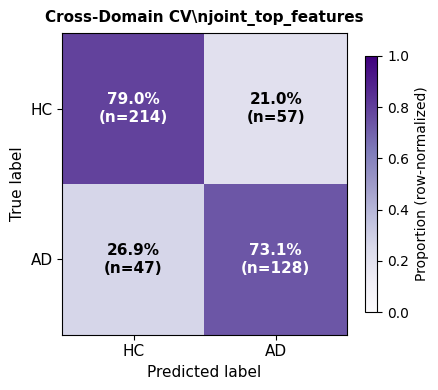

Saved: ../visualizations/cross_out_domain_experiments_visualizations/cross_domain_confusion_matrix_joint_top.png


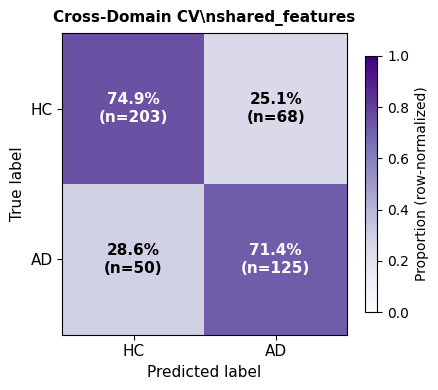

Saved: ../visualizations/cross_out_domain_experiments_visualizations/cross_domain_confusion_matrix_shared.png


In [18]:
import matplotlib.pyplot as plt

# ── Plot cross-domain CV confusion matrices ───────────────────────────────
_title  = 'Cross-Domain CV\\njoint_top_features'
_saveto = os.path.join(VIZ_DIR, 'cross_domain_confusion_matrix_joint_top.png')

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cd_cm_joint_norm, cmap='Purples', vmin=0, vmax=1, aspect='auto')
for _i in range(2):
    for _j in range(2):
        _pct   = cd_cm_joint_norm[_i, _j] * 100
        _count = cd_cm_joint_raw[_i, _j]
        _col   = 'white' if cd_cm_joint_norm[_i, _j] > 0.55 else 'black'
        ax.text(_j, _i, f'{_pct:.1f}%\n(n={_count})',
                ha='center', va='center', fontsize=11,
                fontweight='bold', color=_col)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['HC', 'AD'], fontsize=11)
ax.set_yticklabels(['HC', 'AD'], fontsize=11)
ax.set_xlabel('Predicted label', fontsize=11)
ax.set_ylabel('True label', fontsize=11)
ax.set_title(_title, fontsize=11, fontweight='bold', pad=8)
plt.colorbar(im, ax=ax, label='Proportion (row-normalized)', shrink=0.85)
plt.tight_layout()
plt.savefig(_saveto, dpi=150)
plt.show()
print(f'Saved: {_saveto}')

_title  = 'Cross-Domain CV\\nshared_features'
_saveto = os.path.join(VIZ_DIR, 'cross_domain_confusion_matrix_shared.png')

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cd_cm_shared_norm, cmap='Purples', vmin=0, vmax=1, aspect='auto')
for _i in range(2):
    for _j in range(2):
        _pct   = cd_cm_shared_norm[_i, _j] * 100
        _count = cd_cm_shared_raw[_i, _j]
        _col   = 'white' if cd_cm_shared_norm[_i, _j] > 0.55 else 'black'
        ax.text(_j, _i, f'{_pct:.1f}%\n(n={_count})',
                ha='center', va='center', fontsize=11,
                fontweight='bold', color=_col)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['HC', 'AD'], fontsize=11)
ax.set_yticklabels(['HC', 'AD'], fontsize=11)
ax.set_xlabel('Predicted label', fontsize=11)
ax.set_ylabel('True label', fontsize=11)
ax.set_title(_title, fontsize=11, fontweight='bold', pad=8)
plt.colorbar(im, ax=ax, label='Proportion (row-normalized)', shrink=0.85)
plt.tight_layout()
plt.savefig(_saveto, dpi=150)
plt.show()
print(f'Saved: {_saveto}')


### Out-of-Domain Confusion Matrices

Loaded from `confusion_matrices.csv` (saved during Step 3 above). Each matrix represents one complete train→test evaluation on the full held-out dataset.

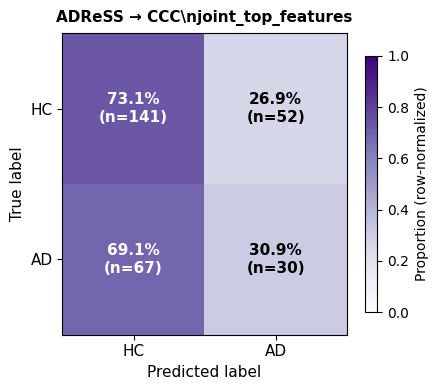

Saved: ../visualizations/cross_out_domain_experiments_visualizations/adress_to_ccc_confusion_matrix_joint_top.png


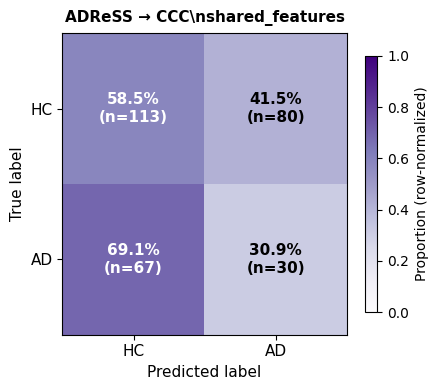

Saved: ../visualizations/cross_out_domain_experiments_visualizations/adress_to_ccc_confusion_matrix_shared.png


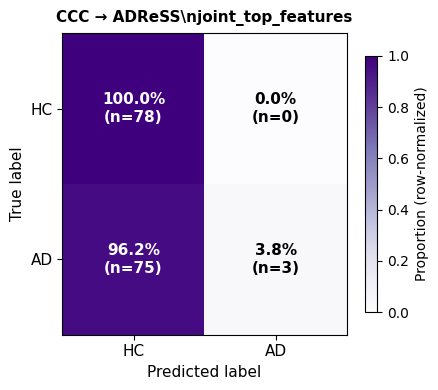

Saved: ../visualizations/cross_out_domain_experiments_visualizations/ccc_to_adress_confusion_matrix_joint_top.png


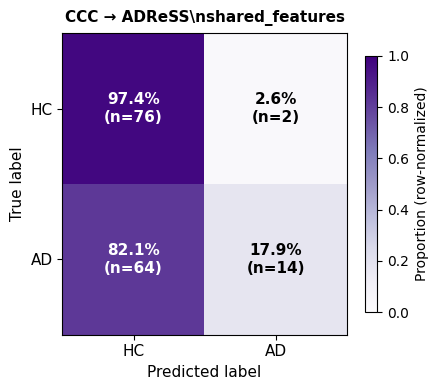

Saved: ../visualizations/cross_out_domain_experiments_visualizations/ccc_to_adress_confusion_matrix_shared.png


In [19]:
import matplotlib.pyplot as plt

# Load OOD confusion matrices from CSV saved in Step 3
_ood_df = pd.read_csv(os.path.join(OUTPUT_DIR, 'confusion_matrices.csv'))


def _ood_cm(df, experiment, feature_set):
    row = df[(df['experiment'] == experiment) &
             (df['feature_set'] == feature_set)].iloc[0]
    raw = np.array([[row['TN'], row['FP']], [row['FN'], row['TP']]], dtype=int)
    return raw, _norm_cm(raw)


ood_a_j_raw,  ood_a_j_norm  = _ood_cm(_ood_df, 'adress_to_ccc', 'joint_top_features')
ood_a_s_raw,  ood_a_s_norm  = _ood_cm(_ood_df, 'adress_to_ccc', 'shared_features')
ood_b_j_raw,  ood_b_j_norm  = _ood_cm(_ood_df, 'ccc_to_adress', 'joint_top_features')
ood_b_s_raw,  ood_b_s_norm  = _ood_cm(_ood_df, 'ccc_to_adress', 'shared_features')

_title  = 'ADReSS → CCC\\njoint_top_features'
_saveto = os.path.join(VIZ_DIR, 'adress_to_ccc_confusion_matrix_joint_top.png')

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(ood_a_j_norm, cmap='Purples', vmin=0, vmax=1, aspect='auto')
for _i in range(2):
    for _j in range(2):
        _pct   = ood_a_j_norm[_i, _j] * 100
        _count = ood_a_j_raw[_i, _j]
        _col   = 'white' if ood_a_j_norm[_i, _j] > 0.55 else 'black'
        ax.text(_j, _i, f'{_pct:.1f}%\n(n={_count})',
                ha='center', va='center', fontsize=11,
                fontweight='bold', color=_col)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['HC', 'AD'], fontsize=11)
ax.set_yticklabels(['HC', 'AD'], fontsize=11)
ax.set_xlabel('Predicted label', fontsize=11)
ax.set_ylabel('True label', fontsize=11)
ax.set_title(_title, fontsize=11, fontweight='bold', pad=8)
plt.colorbar(im, ax=ax, label='Proportion (row-normalized)', shrink=0.85)
plt.tight_layout()
plt.savefig(_saveto, dpi=150)
plt.show()
print(f'Saved: {_saveto}')

_title  = 'ADReSS → CCC\\nshared_features'
_saveto = os.path.join(VIZ_DIR, 'adress_to_ccc_confusion_matrix_shared.png')

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(ood_a_s_norm, cmap='Purples', vmin=0, vmax=1, aspect='auto')
for _i in range(2):
    for _j in range(2):
        _pct   = ood_a_s_norm[_i, _j] * 100
        _count = ood_a_s_raw[_i, _j]
        _col   = 'white' if ood_a_s_norm[_i, _j] > 0.55 else 'black'
        ax.text(_j, _i, f'{_pct:.1f}%\n(n={_count})',
                ha='center', va='center', fontsize=11,
                fontweight='bold', color=_col)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['HC', 'AD'], fontsize=11)
ax.set_yticklabels(['HC', 'AD'], fontsize=11)
ax.set_xlabel('Predicted label', fontsize=11)
ax.set_ylabel('True label', fontsize=11)
ax.set_title(_title, fontsize=11, fontweight='bold', pad=8)
plt.colorbar(im, ax=ax, label='Proportion (row-normalized)', shrink=0.85)
plt.tight_layout()
plt.savefig(_saveto, dpi=150)
plt.show()
print(f'Saved: {_saveto}')

_title  = 'CCC → ADReSS\\njoint_top_features'
_saveto = os.path.join(VIZ_DIR, 'ccc_to_adress_confusion_matrix_joint_top.png')

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(ood_b_j_norm, cmap='Purples', vmin=0, vmax=1, aspect='auto')
for _i in range(2):
    for _j in range(2):
        _pct   = ood_b_j_norm[_i, _j] * 100
        _count = ood_b_j_raw[_i, _j]
        _col   = 'white' if ood_b_j_norm[_i, _j] > 0.55 else 'black'
        ax.text(_j, _i, f'{_pct:.1f}%\n(n={_count})',
                ha='center', va='center', fontsize=11,
                fontweight='bold', color=_col)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['HC', 'AD'], fontsize=11)
ax.set_yticklabels(['HC', 'AD'], fontsize=11)
ax.set_xlabel('Predicted label', fontsize=11)
ax.set_ylabel('True label', fontsize=11)
ax.set_title(_title, fontsize=11, fontweight='bold', pad=8)
plt.colorbar(im, ax=ax, label='Proportion (row-normalized)', shrink=0.85)
plt.tight_layout()
plt.savefig(_saveto, dpi=150)
plt.show()
print(f'Saved: {_saveto}')

_title  = 'CCC → ADReSS\\nshared_features'
_saveto = os.path.join(VIZ_DIR, 'ccc_to_adress_confusion_matrix_shared.png')

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(ood_b_s_norm, cmap='Purples', vmin=0, vmax=1, aspect='auto')
for _i in range(2):
    for _j in range(2):
        _pct   = ood_b_s_norm[_i, _j] * 100
        _count = ood_b_s_raw[_i, _j]
        _col   = 'white' if ood_b_s_norm[_i, _j] > 0.55 else 'black'
        ax.text(_j, _i, f'{_pct:.1f}%\n(n={_count})',
                ha='center', va='center', fontsize=11,
                fontweight='bold', color=_col)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['HC', 'AD'], fontsize=11)
ax.set_yticklabels(['HC', 'AD'], fontsize=11)
ax.set_xlabel('Predicted label', fontsize=11)
ax.set_ylabel('True label', fontsize=11)
ax.set_title(_title, fontsize=11, fontweight='bold', pad=8)
plt.colorbar(im, ax=ax, label='Proportion (row-normalized)', shrink=0.85)
plt.tight_layout()
plt.savefig(_saveto, dpi=150)
plt.show()
print(f'Saved: {_saveto}')


In [20]:
# Save all confusion matrix values to one CSV in the new output folder
_all_cm_rows = []
_cm_inventory = [
    ('cross_domain_cv', 'joint_top_features', cd_cm_joint_raw, cd_cm_joint_norm),
    ('cross_domain_cv', 'shared_features',    cd_cm_shared_raw, cd_cm_shared_norm),
    ('adress_to_ccc',   'joint_top_features', ood_a_j_raw,  ood_a_j_norm),
    ('adress_to_ccc',   'shared_features',    ood_a_s_raw,  ood_a_s_norm),
    ('ccc_to_adress',   'joint_top_features', ood_b_j_raw,  ood_b_j_norm),
    ('ccc_to_adress',   'shared_features',    ood_b_s_raw,  ood_b_s_norm),
]
for _exp, _fs, _raw, _norm in _cm_inventory:
    for _ti, _tl in enumerate(['HC', 'AD']):
        for _pi, _pl in enumerate(['HC', 'AD']):
            _all_cm_rows.append({
                'experiment': _exp, 'feature_set': _fs,
                'true_label': _tl, 'predicted_label': _pl,
                'normalized_value': round(float(_norm[_ti, _pi]), 4),
                'raw_count': int(_raw[_ti, _pi]),
            })
pd.DataFrame(_all_cm_rows).to_csv(
    os.path.join(OUTPUT_DIR, 'cross_ood_domain_confusion_matrices.csv'), index=False)
print('Saved: cross_ood_domain_confusion_matrices.csv')
print(pd.DataFrame(_all_cm_rows).to_string(index=False))


Saved: cross_ood_domain_confusion_matrices.csv
     experiment        feature_set true_label predicted_label  normalized_value  raw_count
cross_domain_cv joint_top_features         HC              HC            0.7897        214
cross_domain_cv joint_top_features         HC              AD            0.2103         57
cross_domain_cv joint_top_features         AD              HC            0.2686         47
cross_domain_cv joint_top_features         AD              AD            0.7314        128
cross_domain_cv    shared_features         HC              HC            0.7491        203
cross_domain_cv    shared_features         HC              AD            0.2509         68
cross_domain_cv    shared_features         AD              HC            0.2857         50
cross_domain_cv    shared_features         AD              AD            0.7143        125
  adress_to_ccc joint_top_features         HC              HC            0.7306        141
  adress_to_ccc joint_top_features         